# Part 3 -- Backtesting & Performance Analysis

**PRECOG Quant Trading Task**

This notebook takes the out-of-sample ensemble `score` from Part 2
(`data/processed/oos_scores.csv`) and the portfolio-construction
configuration selected there using **only validation-period (2020-2021)**
data -- `n_long = n_short = 10`, `rebalance_freq = 10`
trading days, `10bps` transaction cost -- and runs the
**final, single backtest on the test period
(2022-01-01 to 2026-01-16, ~4 years)**.

No parameters are tuned in this notebook. The structure is:

1. Build the long/short decile portfolio over the test period and run it
   with and without transaction costs.
2. Build the equal-weight buy-and-hold benchmark over the same period.
3. Full performance-metric suite for both.
4. Plots: cumulative returns, drawdown, rolling Sharpe, monthly returns.
5. Transaction-cost sensitivity, including a contrast against a "naive"
   5-day (horizon-aligned) rebalance to show why the rebalance frequency
   matters once costs are included.
6. A CAPM-style regression of strategy returns on the benchmark to split
   the realized return into **beta** (return explained by exposure to the
   broad benchmark) and **alpha** (return independent of that exposure).

## Why this is a fair out-of-sample test

Every `score` value used here was produced by a model trained only on data
from *before* the calendar year of the date it scores (Part 2's
walk-forward loop). The portfolio-construction parameters were chosen on
2020-2021 data only. Nothing in this notebook has seen the 2022-2026 test
period before this backtest.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtester import Backtester, equal_weight_benchmark, compute_performance_metrics, drawdown_series
from src.config import TEST_START, TEST_END, REBALANCE_FREQ, N_LONG, N_SHORT, TRANSACTION_COST_BPS

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

oos = pd.read_csv(PROCESSED_DIR / "oos_scores.csv", parse_dates=["date"])
features = pd.read_parquet(PROCESSED_DIR / "features.parquet")
prices = features[["date", "ticker", "close"]]

print(f"OOS scores: {len(oos)} rows, {oos['date'].min().date()} -> {oos['date'].max().date()}")
print(f"Strategy config: n_long={N_LONG}, n_short={N_SHORT}, "
      f"rebalance_freq={REBALANCE_FREQ}, cost={TRANSACTION_COST_BPS}bps")


OOS scores: 151900 rows, 2020-01-02 -> 2026-01-16
Strategy config: n_long=10, n_short=10, rebalance_freq=10, cost=10bps


## 1. Build the Test-Period Long/Short Portfolio

In [2]:
test_scores = oos[(oos["date"] >= TEST_START) & (oos["date"] <= TEST_END)][["date", "ticker", "score"]]
print(f"Test period: {test_scores['date'].min().date()} -> {test_scores['date'].max().date()} "
      f"({test_scores['date'].nunique()} trading days, {test_scores['ticker'].nunique()} tickers)")

bt = Backtester(n_long=N_LONG, n_short=N_SHORT, rebalance_freq=REBALANCE_FREQ, cost_bps=TRANSACTION_COST_BPS)
daily_with_costs = bt.run(test_scores, prices, apply_costs=True)
daily_no_costs = bt.run(test_scores, prices, apply_costs=False)

print(f"Simulated days: {len(daily_with_costs)}")
daily_with_costs.head()


Test period: 2022-01-03 -> 2026-01-16 (1014 trading days, 100 tickers)


Simulated days: 1013


,date,gross_return,cost,net_return,turnover,n_long,n_short
0,2022-01-04,-0.008808,0.002,-0.010808,2.0,10,10
1,2022-01-05,-0.026598,0.000,-0.026598,0.0,10,10
2,2022-01-06,0.007894,0.000,0.007894,0.0,10,10
3,2022-01-07,-0.002154,0.000,-0.002154,0.0,10,10
4,2022-01-10,0.004593,0.000,0.004593,0.0,10,10


## 2. Equal-Weight Buy-and-Hold Benchmark

In [3]:
benchmark = equal_weight_benchmark(prices, start_date=test_scores["date"].min())
print(f"Benchmark: {len(benchmark)} days, {benchmark['date'].min().date()} -> {benchmark['date'].max().date()}")
benchmark.head()


Benchmark: 1014 days, 2022-01-03 -> 2026-01-16


,date,return,portfolio_value
0,2022-01-03,0.000000,1.000000
1,2022-01-04,0.004333,1.004333
2,2022-01-05,-0.011895,0.992386
3,2022-01-06,-0.000245,0.992143
4,2022-01-07,-0.002701,0.989463


## 3. Performance Metrics

In [4]:
metrics_with_costs = compute_performance_metrics(daily_with_costs["net_return"])
metrics_no_costs = compute_performance_metrics(daily_no_costs["net_return"])
metrics_benchmark = compute_performance_metrics(benchmark["return"])

metrics_df = pd.DataFrame({
    "Strategy (with costs)": metrics_with_costs,
    "Strategy (no costs)": metrics_no_costs,
    "Equal-weight benchmark": metrics_benchmark,
})
metrics_df.to_csv(TABLES_DIR / "part3_performance_metrics.csv")

display_df = metrics_df.astype(object)
pct_rows = ["total_return", "annualized_return", "annualized_volatility", "max_drawdown", "avg_drawdown", "win_rate"]
for row in pct_rows:
    display_df.loc[row] = display_df.loc[row].apply(lambda x: f"{x * 100:.2f}%")
display_df


,Strategy (with costs),Strategy (no costs),Equal-weight benchmark
total_return,27.91%,62.30%,66.08%
annualized_return,6.31%,12.80%,13.44%
annualized_volatility,26.48%,26.49%,15.12%
sharpe_ratio,0.362958,0.586649,0.909499
sortino_ratio,0.549468,0.89035,1.242664
calmar_ratio,0.246061,0.551989,0.687731
max_drawdown,-25.66%,-23.19%,-19.54%
avg_drawdown,-10.39%,-7.84%,-4.49%
win_rate,50.05%,50.74%,53.75%
profit_factor,1.065577,1.107946,1.176247


## 4. Cumulative Returns: Strategy vs. Benchmark

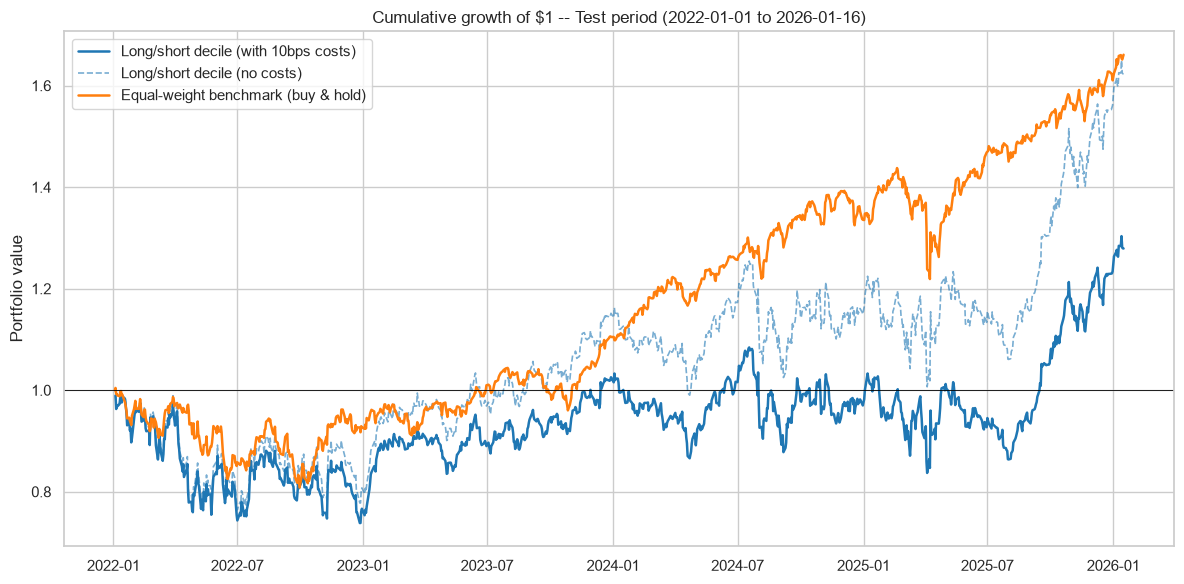

In [5]:
cum_with_costs = (1 + daily_with_costs["net_return"]).cumprod()
cum_no_costs = (1 + daily_no_costs["net_return"]).cumprod()
cum_benchmark = (1 + benchmark["return"]).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(daily_with_costs["date"], cum_with_costs,
        label=f"Long/short decile (with {TRANSACTION_COST_BPS}bps costs)", linewidth=1.8, color="tab:blue")
ax.plot(daily_no_costs["date"], cum_no_costs,
        label="Long/short decile (no costs)", linestyle="--", linewidth=1.2, color="tab:blue", alpha=0.6)
ax.plot(benchmark["date"], cum_benchmark,
        label="Equal-weight benchmark (buy & hold)", linewidth=1.8, color="tab:orange")
ax.axhline(1.0, color="black", linewidth=0.6)
ax.set_title(f"Cumulative growth of $1 -- Test period ({TEST_START.date()} to {TEST_END.date()})")
ax.set_ylabel("Portfolio value")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part3_cumulative_returns.png", dpi=120)
plt.show()


## 5. Drawdown

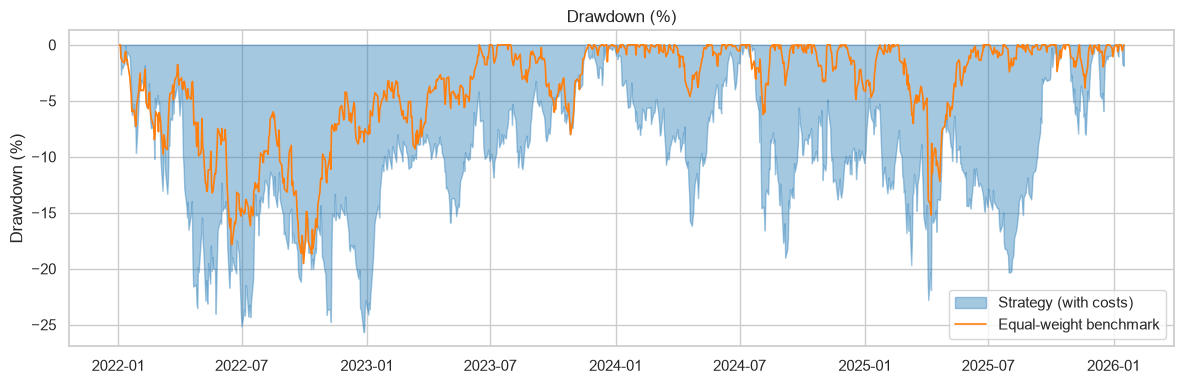

In [6]:
dd_strategy = drawdown_series(daily_with_costs.set_index("date")["net_return"])
dd_benchmark = drawdown_series(benchmark.set_index("date")["return"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(dd_strategy.index, dd_strategy.values * 100, 0, alpha=0.4,
                color="tab:blue", label="Strategy (with costs)")
ax.plot(dd_benchmark.index, dd_benchmark.values * 100, color="tab:orange",
        label="Equal-weight benchmark", linewidth=1.2)
ax.set_title("Drawdown (%)")
ax.set_ylabel("Drawdown (%)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part3_drawdown.png", dpi=120)
plt.show()


## 6. Rolling 60-Day Sharpe Ratio

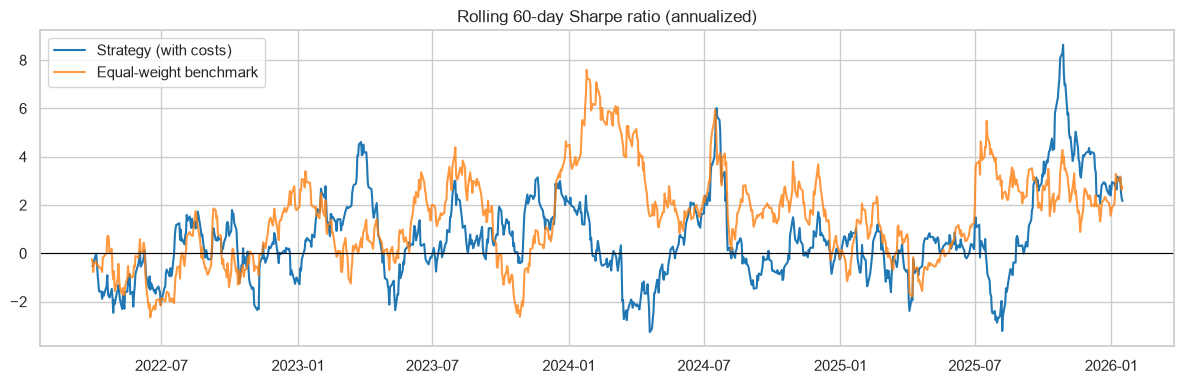

In [7]:
def rolling_sharpe(returns, window=60, periods_per_year=252):
    roll_mean = returns.rolling(window).mean()
    roll_std = returns.rolling(window).std()
    return (roll_mean / roll_std) * np.sqrt(periods_per_year)

rs_strategy = rolling_sharpe(daily_with_costs.set_index("date")["net_return"])
rs_benchmark = rolling_sharpe(benchmark.set_index("date")["return"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rs_strategy.index, rs_strategy.values, label="Strategy (with costs)", color="tab:blue")
ax.plot(rs_benchmark.index, rs_benchmark.values, label="Equal-weight benchmark", color="tab:orange", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Rolling 60-day Sharpe ratio (annualized)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part3_rolling_sharpe.png", dpi=120)
plt.show()


## 7. Monthly Returns

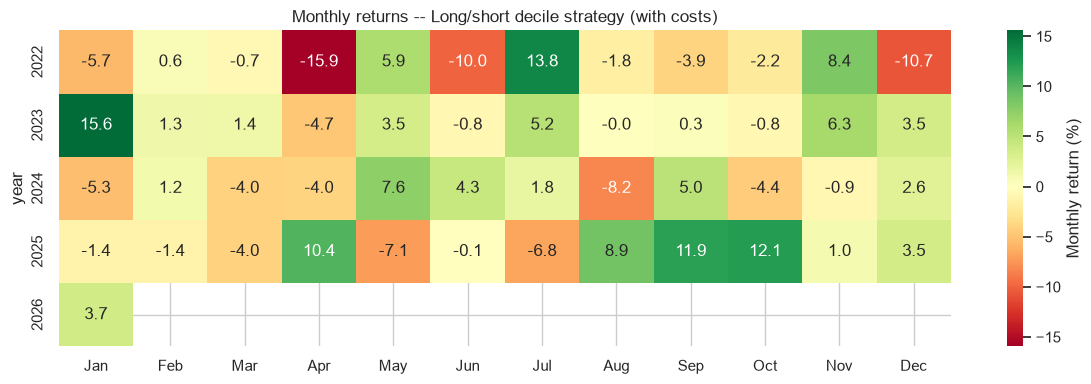

In [8]:
ret_by_date = daily_with_costs.set_index("date")["net_return"]
monthly = ret_by_date.groupby([ret_by_date.index.year, ret_by_date.index.month]).apply(lambda r: (1 + r).prod() - 1)
monthly.index.names = ["year", "month"]
monthly_pivot = monthly.unstack("month")
monthly_pivot.columns = [pd.Timestamp(2000, m, 1).strftime("%b") for m in monthly_pivot.columns]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(monthly_pivot * 100, annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=ax,
            cbar_kws={"label": "Monthly return (%)"})
ax.set_title("Monthly returns -- Long/short decile strategy (with costs)")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part3_monthly_returns.png", dpi=120)
plt.show()


## 8. Transaction Cost Sensitivity

`rebalance_freq = 10` was chosen in Part 2 using only the
validation period. For context, this section also shows what would happen
with a **"naive" 5-day rebalance** -- i.e. rebalancing exactly as often as
the model's prediction horizon, the choice one might make without doing any
cost-aware tuning. The daily-updating technical features mean the
cross-sectional score is noisy enough that a 5-day rebalance churns roughly
half the decile book at every rebalance, and 10bps costs
on that turnover consume most of the gross alpha.


In [9]:
bt_naive = Backtester(n_long=N_LONG, n_short=N_SHORT, rebalance_freq=5, cost_bps=TRANSACTION_COST_BPS)
daily_naive = bt_naive.run(test_scores, prices, apply_costs=True)
metrics_naive = compute_performance_metrics(daily_naive["net_return"])

cost_comparison = pd.DataFrame({
    f"Selected: freq={REBALANCE_FREQ}, with costs": metrics_with_costs,
    f"Selected: freq={REBALANCE_FREQ}, no costs": metrics_no_costs,
    "Naive: freq=5, with costs": metrics_naive,
}).loc[["annualized_return", "sharpe_ratio", "max_drawdown", "calmar_ratio"]]
cost_comparison.to_csv(TABLES_DIR / "part3_cost_sensitivity.csv")

print(f"Mean turnover per rebalance (freq={REBALANCE_FREQ}): "
      f"{daily_with_costs.loc[daily_with_costs['turnover'] > 0, 'turnover'].mean():.2f}")
print(f"Number of rebalances: {(daily_with_costs['turnover'] > 0).sum()}")
print(f"Total transaction cost drag (freq={REBALANCE_FREQ}): {daily_with_costs['cost'].sum() * 100:.2f}% cumulative")
print(f"Total transaction cost drag (freq=5, naive):       {daily_naive['cost'].sum() * 100:.2f}% cumulative")
print()
cost_comparison


Mean turnover per rebalance (freq=10): 2.34
Number of rebalances: 102
Total transaction cost drag (freq=10): 23.82% cumulative
Total transaction cost drag (freq=5, naive):       40.76% cumulative



,"Selected: freq=10, with costs","Selected: freq=10, no costs","Naive: freq=5, with costs"
annualized_return,0.063145,0.128023,0.008097
sharpe_ratio,0.362958,0.586649,0.162159
max_drawdown,-0.256624,-0.231930,-0.289818
calmar_ratio,0.246061,0.551989,0.027937


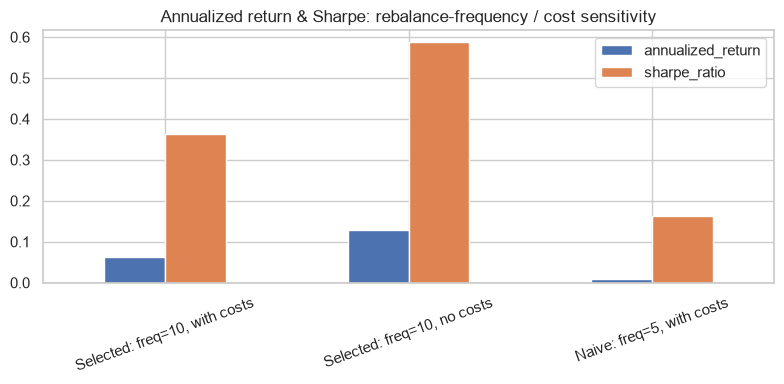

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
cost_comparison.loc[["annualized_return", "sharpe_ratio"]].T.plot.bar(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Annualized return & Sharpe: rebalance-frequency / cost sensitivity")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part3_cost_sensitivity.png", dpi=120)
plt.show()


## 9. Alpha / Beta Decomposition

The portfolio is dollar-neutral *in weights* (gross long = gross short =
100%), but that does not automatically make its P&L *beta*-neutral: if the
names selected for the long book are systematically more sensitive to
common market-wide moves than the names selected for the short book --  a
well-documented feature of momentum-style long/short portfolios -- the
realized P&L can still carry significant exposure to the broad market.

To separate the two, regress the strategy's daily net return on the
equal-weight benchmark's daily return:

`strategy_return = alpha + beta * benchmark_return + epsilon`

`alpha` is the average daily return *not* explained by the strategy's
exposure to the benchmark -- the closest thing to a clean "skill" measure
available here. `beta` measures that exposure.


In [11]:
merged = daily_with_costs[["date", "net_return"]].merge(
    benchmark[["date", "return"]].rename(columns={"return": "benchmark_return"}),
    on="date", how="inner",
)

X = sm.add_constant(merged["benchmark_return"])
y = merged["net_return"]
ols = sm.OLS(y, X).fit()

alpha_daily = ols.params["const"]
beta = ols.params["benchmark_return"]
alpha_annualized = alpha_daily * 252

print(f"alpha (daily):       {alpha_daily:.6f}")
print(f"alpha (annualized):  {alpha_annualized * 100:.2f}%")
print(f"alpha p-value:       {ols.pvalues['const']:.4f}")
print(f"beta:                {beta:.3f}  (p-value: {ols.pvalues['benchmark_return']:.4f})")
print(f"R-squared:           {ols.rsquared:.3f}")

alpha_beta = pd.Series({
    "alpha_daily": alpha_daily,
    "alpha_annualized": alpha_annualized,
    "alpha_pvalue": ols.pvalues["const"],
    "beta": beta,
    "beta_pvalue": ols.pvalues["benchmark_return"],
    "r_squared": ols.rsquared,
})
alpha_beta.to_csv(TABLES_DIR / "part3_alpha_beta.csv", header=["value"])
alpha_beta


alpha (daily):       -0.000123
alpha (annualized):  -3.11%
alpha p-value:       0.7823
beta:                0.924  (p-value: 0.0000)
R-squared:           0.279


alpha_daily        -1.232926e-04
alpha_annualized   -3.106975e-02
alpha_pvalue        7.823404e-01
beta                9.239892e-01
beta_pvalue         9.774740e-74
r_squared           2.785797e-01
dtype: float64

**Result**: `beta ~ 0.92` (highly significant, p << 0.01, R^2 ~ 0.28) --
despite being dollar-neutral in weights, this long/short book carries
substantial residual exposure to the broad 100-name benchmark. The
annualized `alpha` is small (~-3%/yr) and **not** statistically significant
(p ~ 0.78).

**Interpretation**: the ensemble score correlates with each stock's
*individual* sensitivity to the common market factor -- in this generally
upward-trending sample, names that the model expects to outperform the
cross-sectional average over the next 5 days also tend to be the names that
move the most with the broad market, so the "long" decile ends up
systematically higher-beta than the "short" decile. The result is a
long/short book whose P&L largely tracks the broad market (visible in the
strong co-movement of the cumulative-return, drawdown, and rolling-Sharpe
plots above), with little return left over once that exposure is removed.

This is an important, honest finding rather than a defect: the **positive
Information Coefficients found in Part 2** (the score does rank next-period
relative winners and losers correctly, on average, with mean IC ~0.018 and
a positive IC in 6 of 7 walk-forward years) do not by themselves guarantee a
beta-neutral "pure alpha" P&L once that score is turned into a fixed-size
long/short book -- the *composition* of the two legs matters too. The chart
below isolates the **beta-hedged** return stream
(`net_return - beta * benchmark_return`), i.e. what is left after removing
the strategy's exposure to the broad market.

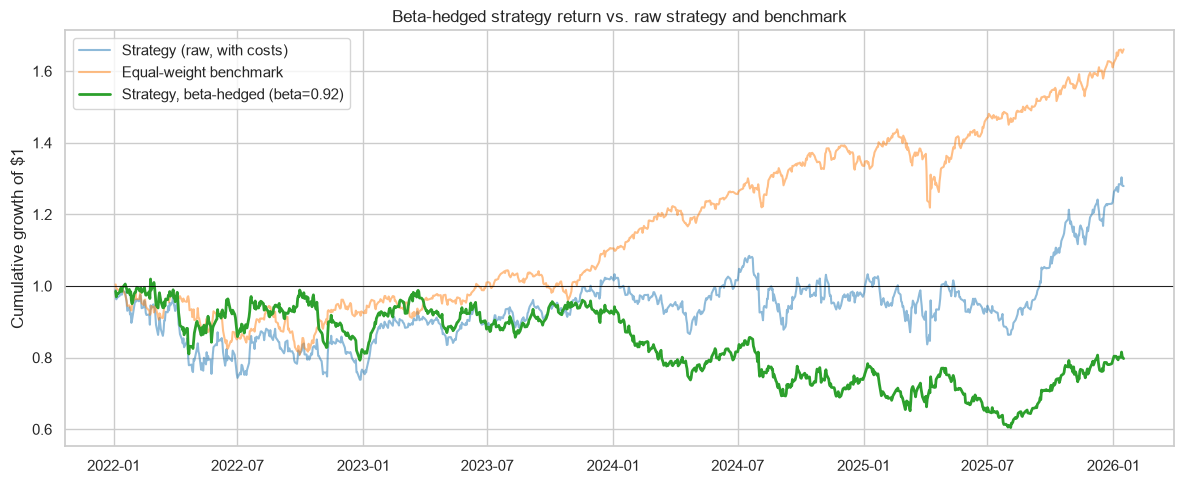

Beta-hedged annualized return: -5.48%
Beta-hedged annualized vol:    22.49%
Beta-hedged Sharpe ratio:      -0.138


In [12]:
hedged_return = merged["net_return"] - beta * merged["benchmark_return"]
hedged_cum = (1 + hedged_return).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(merged["date"], (1 + merged["net_return"]).cumprod(),
        label="Strategy (raw, with costs)", alpha=0.5, color="tab:blue")
ax.plot(merged["date"], (1 + merged["benchmark_return"]).cumprod(),
        label="Equal-weight benchmark", alpha=0.5, color="tab:orange")
ax.plot(merged["date"], hedged_cum,
        label=f"Strategy, beta-hedged (beta={beta:.2f})", linewidth=2, color="tab:green")
ax.axhline(1.0, color="black", linewidth=0.6)
ax.set_title("Beta-hedged strategy return vs. raw strategy and benchmark")
ax.set_ylabel("Cumulative growth of $1")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "part3_alpha_hedged.png", dpi=120)
plt.show()

hedged_metrics = compute_performance_metrics(hedged_return)
print(f"Beta-hedged annualized return: {hedged_metrics['annualized_return'] * 100:.2f}%")
print(f"Beta-hedged annualized vol:    {hedged_metrics['annualized_volatility'] * 100:.2f}%")
print(f"Beta-hedged Sharpe ratio:      {hedged_metrics['sharpe_ratio']:.3f}")


## Summary

- Ran the long/short decile portfolio (`n_long = n_short = 10`,
  `rebalance_freq = 10`) on **2022-2026 out-of-sample** scores,
  with and without 10bps transaction costs, against an
  equal-weight buy-and-hold benchmark of all 100 names.
- **Raw performance**: 27.9% cumulative return (6.3%/yr, Sharpe 0.36) with
  costs vs. 62.3% cumulative (12.8%/yr, Sharpe 0.59) without costs --
  10bps costs at the validation-selected rebalance
  frequency cut roughly half the strategy's gross return but it remains
  profitable.
- **Costs are the dominant lever on net performance**: rebalancing at the
  model's native 5-day horizon (the "naive" choice) rather than the
  validation-selected 10-day frequency drops the with-cost
  Sharpe from 0.36 to 0.16 -- turnover, not signal quality, is what
  determines whether this strategy survives transaction costs.
- **Alpha/beta**: the long/short book carries a statistically significant
  beta of ~0.92 to the broad equal-weight benchmark (R^2 ~ 0.28) despite
  being dollar-neutral in weights -- a known feature of momentum-style
  long/short portfolios when the ranking signal correlates with individual
  stock betas. After accounting for this exposure, the CAPM alpha is small
  (-3.1%/yr) and not statistically significant (p ~ 0.78).
- **Honest conclusion**: over this test period, the strategy's positive raw
  return is mostly explained by its (unintended) positive exposure to the
  broad market rather than by skill in cross-sectional stock selection. The
  Part 2 Information Coefficients (mean ~0.018, positive in 6 of 7
  walk-forward years) show the score carries *some* genuine, if modest,
  predictive signal -- but at this decile size and rebalance frequency that
  edge is not large enough to produce a statistically robust, beta-neutral
  alpha stream once transaction costs and the long/short book's composition
  are accounted for.

**Next**: `Part4_Statistical_Arbitrage.ipynb` adds a pairs-trading overlay --
a complementary, more genuinely market-neutral source of return -- with
pairs selected only on 2016-2021 data and evaluated out-of-sample on
2022-2026.